# Trends datapost plots

This notebook recreates the five figures in `Trends datapost.docx` with a consistent, publication-ready visual style. Every figure reads from `cfsrALL.csv`, and the shared data load is explicitly limited to survey years 2020–2025.

The violence, shoutdown, comfort, and difficult-topic estimates are survey weighted. The left/right speaker-tolerance figure preserves the calculation from Chloe Ratner's `chloe/tolerance_article_charts.ipynb`: it uses unweighted complete-case averages among respondents with valid gender and party-ID codes.

Generated files are saved in `trends_article_outputs/`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd

# The notebook and cfsrALL.csv normally live in the home directory.
BASE_DIR = Path.home() if (Path.home() / "cfsrALL.csv").exists() else Path.cwd()
CSV_PATH = BASE_DIR / "cfsrALL.csv"
OUT_DIR = BASE_DIR / "trends_article_outputs"
OUT_DIR.mkdir(exist_ok=True)

START_YEAR = 2020
END_YEAR = 2025
YEAR_COL = "datayear"
WEIGHT_COL = "weight"

# FIRE colors used in previously published charts.
FIRE = {
    "navy": "#003d6e",
    "blue": "#00a6de",
    "light_blue": "#85c7e3",
    "dark": "#31261d",
    "red": "#cb333b",
    "orange": "#f24f00",
    "gold": "#f7a30a",
    "green": "#009a44",
    "purple": "#6a1b9a",
    "gray": "#4b5563",
    "grid": "#d1d5db",
}

CHLOE_QUESTION_SETS = {
    2021: {
        "right": ["spk_abortion", "spk_trans", "spk_blm", "spk_lockdown"],
        "left": ["spk_whites", "spk_loot", "spk_abolishpolice", "spk_religlib"],
    },
    2022: {
        "right": ["spk_abortion", "spk_trans", "spk_blm", "spk_election"],
        "left": ["spk_whites", "spk_guns", "spk_religlib", "spk_immigration"],
    },
    2023: {
        "right": ["spk_abortion", "spk_trans", "spk_blm"],
        "left": ["spk_whites", "spk_guns", "spk_religlib"],
    },
    2024: {
        "right": ["spk_abortion", "spk_trans", "spk_blm"],
        "left": ["spk_cathped", "spk_policekkk", "spk_kidtrans"],
    },
    2025: {
        "right": ["spk_abortion", "spk_trans", "spk_blm"],
        "left": ["spk_cathped", "spk_policekkk", "spk_kidtrans"],
    },
}

COMFORT_ITEMS = {
    "cf_pubprof": "Publicly disagree with a professor",
    "cf_wrtprof": "Disagree in a written assignment",
    "cf_inclass": "Express views in class",
    "cf_quad": "Discuss views in a campus common space",
    "cf_socmedia": "Post an unpopular opinion on social media",
}

# The four most frequently selected difficult topics in weighted 2025 data.
DIFFICULT_TOPIC_ITEMS = {
    "tk_ipc": "Israeli-Palestinian conflict",
    "tk_abortion": "Abortion",
    "tk_preselec": "2024 presidential election",
    "tk_trans": "Transgender rights",
}

speaker_cols = sorted({
    col
    for question_set in CHLOE_QUESTION_SETS.values()
    for col in question_set["right"] + question_set["left"]
})
USECOLS = sorted({
    YEAR_COL,
    WEIGHT_COL,
    "act_viol",
    "act_shout",
    "gender_bin",
    "fire_partyid",
    "cp_partyid",
    *DIFFICULT_TOPIC_ITEMS.keys(),
    *COMFORT_ITEMS.keys(),
    *speaker_cols,
})

data = pd.read_csv(CSV_PATH, usecols=USECOLS, low_memory=False)
for col in USECOLS:
    data[col] = pd.to_numeric(data[col], errors="coerce")
data = data[data[YEAR_COL].between(START_YEAR, END_YEAR)].copy()
assert int(data[YEAR_COL].min()) == START_YEAR
assert int(data[YEAR_COL].max()) == END_YEAR
print(f"Loaded {len(data):,} rows from {CSV_PATH.name}: {START_YEAR}–{END_YEAR}.")

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 18,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.labelweight": "bold",
    "legend.fontsize": 10.5,
})


def weighted_mean(values, weights):
    values = pd.to_numeric(values, errors="coerce")
    weights = pd.to_numeric(weights, errors="coerce")
    valid = values.notna() & weights.notna() & weights.gt(0)
    if not valid.any():
        return np.nan
    return np.average(values[valid], weights=weights[valid])


def weighted_percent(condition, weights):
    return weighted_mean(pd.Series(condition, dtype=float), weights) * 100


def style_axes(ax, years, *, ylim, ylabel, percent=False):
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.set_xticks(list(years))
    ax.set_ylim(*ylim)
    ax.set_axisbelow(True)
    ax.grid(axis="y", color=FIRE["grid"], linewidth=0.9, alpha=0.8)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(axis="both", length=0, pad=7)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("semibold")
    if percent:
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))


def add_point_labels(ax, x, y, *, color, suffix="%", decimals=0, offset=8):
    for x_value, y_value in zip(x, y):
        ax.annotate(
            f"{y_value:.{decimals}f}{suffix}",
            (x_value, y_value),
            xytext=(0, offset),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9.5,
            fontweight="semibold",
            color=color,
        )


def finish_plot(fig, ax, *, title, filename, chart_credit, source_years, legend=None):
    ax.set_title(title, pad=18)
    if legend:
        ax.legend(**legend)
    fig.text(
        0.98,
        0.018,
        f"Chart: {chart_credit}\nSource: FIRE's College Free Speech Rankings Survey ({source_years} data)",
        ha="right",
        va="bottom",
        fontsize=9,
        color=FIRE["gray"],
    )
    fig.tight_layout(rect=[0.02, 0.065, 0.98, 0.97])
    output_path = OUT_DIR / filename
    fig.savefig(output_path, dpi=220, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved: {output_path}")


Loaded 284,372 rows from cfsrALL.csv: 2020–2025.


,year,percent,n_valid
0,2020,17.9,19899
1,2021,23.8,37104
2,2022,20.4,44847
3,2023,26.9,55102
4,2024,31.8,58807
5,2025,33.6,68510


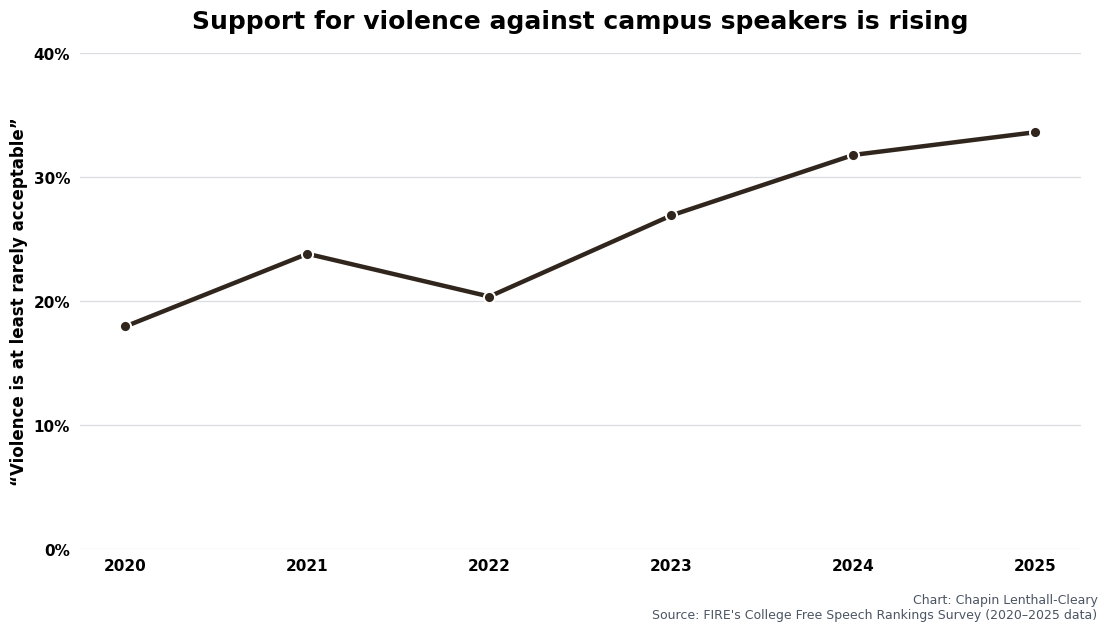

Saved: /Users/chapin.lenthall-cleary/trends_article_outputs/violence_acceptability_trend_2020_2025.png


In [2]:
# 1. Support for violence against speakers
violence_rows = []
for year, year_df in data.groupby(YEAR_COL, sort=True):
    valid = year_df["act_viol"].isin([1, 2, 3, 4])
    sub = year_df.loc[valid]
    violence_rows.append({
        "year": int(year),
        "percent": weighted_percent(
            sub["act_viol"].isin([1, 2, 3]), sub[WEIGHT_COL]
        ),
        "n_valid": int(valid.sum()),
    })
violence_trend = pd.DataFrame(violence_rows)
display(violence_trend.round({"percent": 1}))

fig, ax = plt.subplots(figsize=(11.5, 6.6))
ax.plot(
    violence_trend["year"],
    violence_trend["percent"],
    color=FIRE["dark"],
    linewidth=3.2,
    marker="o",
    markersize=8,
    markeredgecolor="white",
    markeredgewidth=1.4,
)
style_axes(
    ax,
    violence_trend["year"],
    ylim=(0, 40),
    ylabel="“Violence is at least rarely acceptable”",
    percent=True,
)
ax.set_yticks([0, 10, 20, 30, 40])
finish_plot(
    fig,
    ax,
    title="Support for violence against campus speakers is rising",
    filename="violence_acceptability_trend_2020_2025.png",
    chart_credit="Chapin Lenthall-Cleary",
    source_years="2020–2025",
)


,year,percent,n_valid
0,2020,61.0,19889
1,2021,66.0,37104
2,2022,62.3,44846
3,2023,63.4,55101
4,2024,68.5,58807
5,2025,71.7,68510


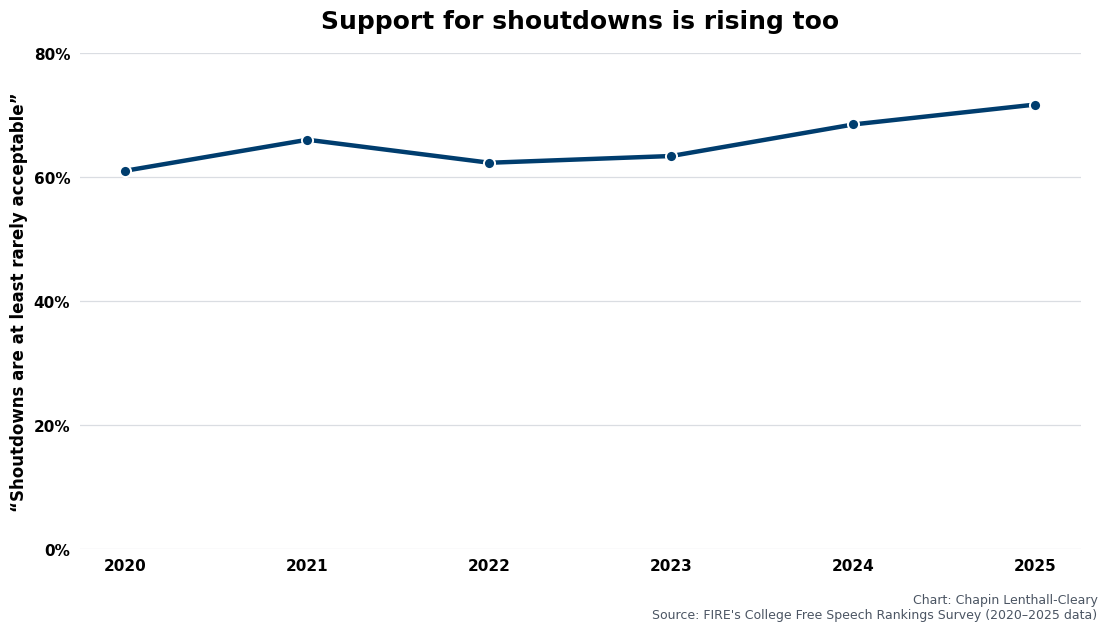

Saved: /Users/chapin.lenthall-cleary/trends_article_outputs/shoutdown_trend_2020_2025.png


In [3]:
# 2. Support for shoutdowns
shoutdown_rows = []
for year, year_df in data.groupby(YEAR_COL, sort=True):
    valid = year_df["act_shout"].isin([1, 2, 3, 4])
    sub = year_df.loc[valid]
    shoutdown_rows.append({
        "year": int(year),
        "percent": weighted_percent(
            sub["act_shout"].isin([1, 2, 3]), sub[WEIGHT_COL]
        ),
        "n_valid": int(valid.sum()),
    })
shoutdown_trend = pd.DataFrame(shoutdown_rows)
display(shoutdown_trend.round({"percent": 1}))

fig, ax = plt.subplots(figsize=(11.5, 6.6))
ax.plot(
    shoutdown_trend["year"],
    shoutdown_trend["percent"],
    color=FIRE["navy"],
    linewidth=3.2,
    marker="o",
    markersize=8,
    markeredgecolor="white",
    markeredgewidth=1.4,
)
style_axes(
    ax,
    shoutdown_trend["year"],
    ylim=(0, 80),
    ylabel="“Shoutdowns are at least rarely acceptable”",
    percent=True,
)
ax.set_yticks([0, 20, 40, 60, 80])
finish_plot(
    fig,
    ax,
    title="Support for shoutdowns is rising too",
    filename="shoutdown_trend_2020_2025.png",
    chart_credit="Chapin Lenthall-Cleary",
    source_years="2020–2025",
)


,year,avg_left_tolerance,avg_right_tolerance,n_complete
0,2021,51.9,29.3,33298
1,2022,59.8,32.4,38119
2,2023,58.5,34.5,46886
3,2024,47.3,37.3,48781
4,2025,41.2,33.1,59840


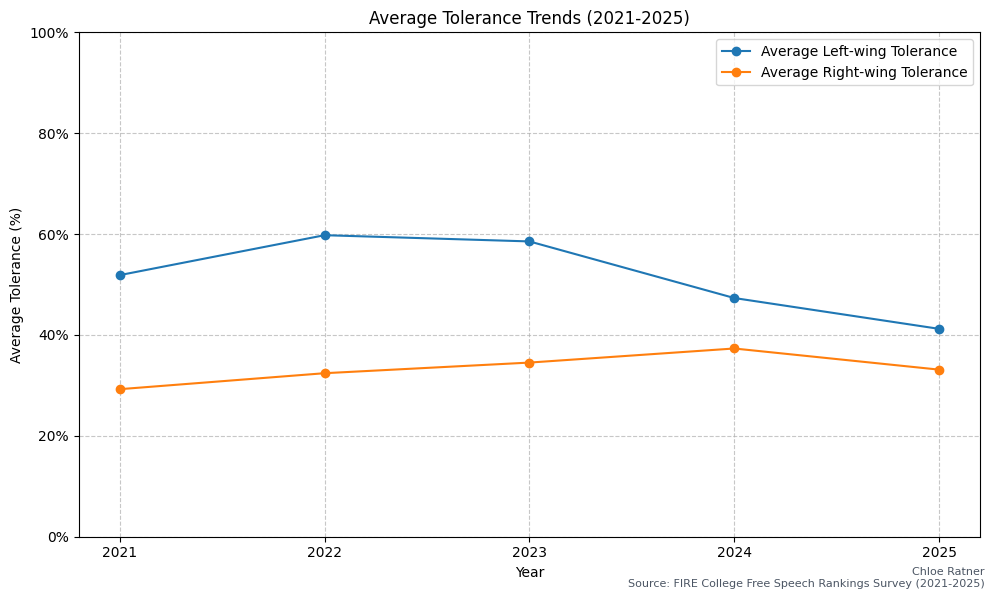

Saved: /Users/chapin.lenthall-cleary/trends_article_outputs/speaker_tolerance_trends_chloe_2021_2025.png


In [4]:
# 3. Left- and right-wing speaker tolerance
# Calculation pulled from chloe/tolerance_article_charts.ipynb.
# Only the shared source path, 2025 cutoff, and saved-output path are adapted here.
def scale_triad_to_pct(sum_vals, k=3):
    """Map a sum of k items coded 1–4 from k..4k onto 0..100."""
    return (sum_vals - k) / (3 * k) * 100.0


def build_partyid_like_chloe(frame):
    fire = pd.to_numeric(frame["fire_partyid"], errors="coerce")
    cp = pd.to_numeric(frame["cp_partyid"], errors="coerce")
    partyid = np.where(
        fire.between(1, 7),
        fire,
        np.where(cp.between(1, 7), cp, np.nan),
    )
    partyid = np.where(
        pd.isna(partyid) & ((fire == 8) | (cp == 8)), 8, partyid
    )
    return pd.Series(partyid, index=frame.index).astype("Int64")


chloe_data = data.copy()
chloe_data["partyid"] = build_partyid_like_chloe(chloe_data)
yearly_tolerance_data = []
for year in range(2021, END_YEAR + 1):
    right_triad = CHLOE_QUESTION_SETS[year]["right"]
    left_triad = CHLOE_QUESTION_SETS[year]["left"]
    speaker_items = right_triad + left_triad

    year_df = chloe_data[
        chloe_data[YEAR_COL].eq(year)
        & chloe_data["gender_bin"].isin([1, 2])
        & chloe_data["partyid"].isin(range(1, 8))
    ].copy()
    in_range = year_df[speaker_items].ge(1) & year_df[speaker_items].le(4)
    year_df = year_df[in_range.all(axis=1)].copy()

    year_df["right_sum"] = year_df[right_triad].sum(axis=1).astype(int)
    year_df["left_sum"] = year_df[left_triad].sum(axis=1).astype(int)
    year_df["right_pct"] = scale_triad_to_pct(
        year_df["right_sum"], k=len(right_triad)
    )
    year_df["left_pct"] = scale_triad_to_pct(
        year_df["left_sum"], k=len(left_triad)
    )
    yearly_tolerance_data.append({
        "year": year,
        "avg_left_tolerance": year_df["left_pct"].mean(),
        "avg_right_tolerance": year_df["right_pct"].mean(),
        "n_complete": len(year_df),
    })
tolerance_trends = pd.DataFrame(yearly_tolerance_data)
display(tolerance_trends.round(1))

# Preserve the appearance of Chloe's original chart.
with plt.rc_context(plt.rcParamsDefault):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(
        tolerance_trends["year"],
        tolerance_trends["avg_left_tolerance"],
        marker="o",
        label="Average Left-wing Tolerance",
    )
    ax.plot(
        tolerance_trends["year"],
        tolerance_trends["avg_right_tolerance"],
        marker="o",
        label="Average Right-wing Tolerance",
    )
    ax.set_title("Average Tolerance Trends (2021-2025)")
    ax.set_xlabel("Year")
    ax.set_ylabel("Average Tolerance (%)")
    ax.set_xticks(tolerance_trends["year"])
    ax.set_ylim(0, 100)
    ax.grid(True, linestyle="--", alpha=0.7)
    ax.legend()
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
    fig.text(
        0.99,
        0.01,
        "Chloe Ratner\nSource: FIRE College Free Speech Rankings Survey (2021-2025)",
        ha="right",
        va="bottom",
        fontsize=8,
        color="#4b5563",
    )
    fig.tight_layout()
    output_path = OUT_DIR / "speaker_tolerance_trends_chloe_2021_2025.png"
    fig.savefig(output_path, dpi=220, bbox_inches="tight", facecolor="white")
    plt.show()
print(f"Saved: {output_path}")


question,Disagree in a written assignment,Discuss views in a campus common space,Express views in class,Post an unpopular opinion on social media,Publicly disagree with a professor
year,,,,,
2020,NaN,NaN,2.84,2.20,2.38
2021,2.65,2.68,2.50,2.25,2.27
2022,2.66,2.70,2.50,2.26,2.28
2023,2.39,2.42,2.30,2.02,2.08
2024,2.47,2.47,2.40,2.10,2.25
2025,2.48,2.52,2.44,2.12,2.27


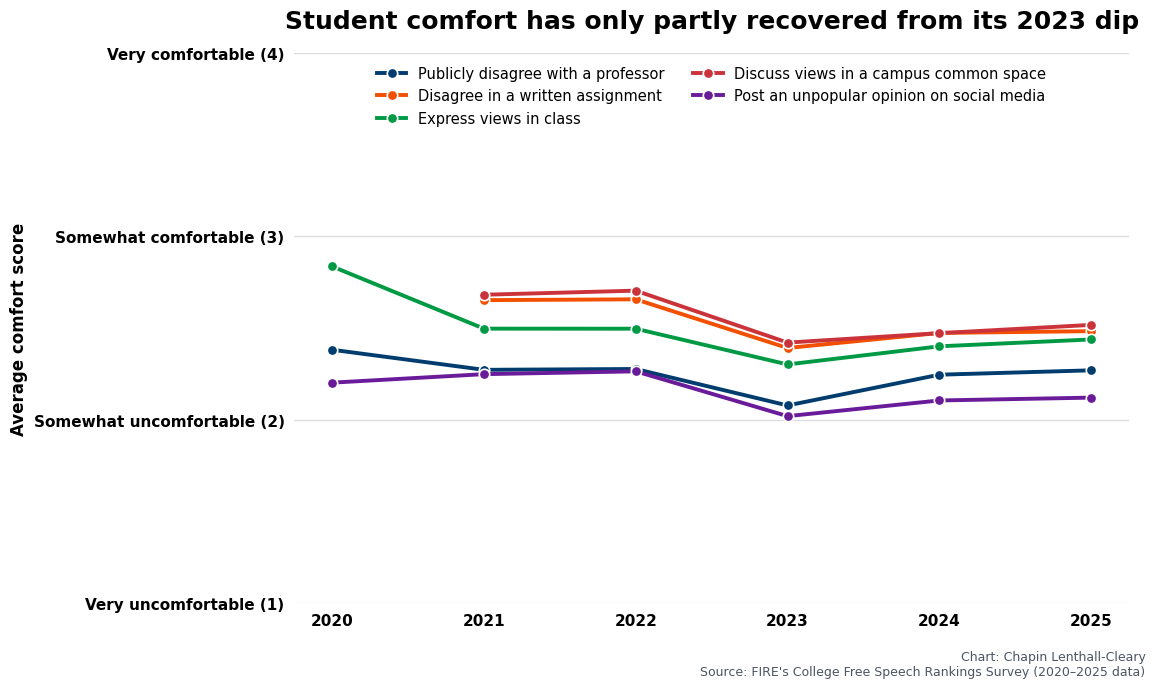

Saved: /Users/chapin.lenthall-cleary/trends_article_outputs/comfort_trends_2020_2025.png
Comfort scale: 1 = Very uncomfortable; 2 = Somewhat uncomfortable; 3 = Somewhat comfortable; 4 = Very comfortable.


In [5]:
# 4. Comfort expressing controversial or unpopular opinions
comfort_rows = []
for year, year_df in data.groupby(YEAR_COL, sort=True):
    for item, label in COMFORT_ITEMS.items():
        valid = year_df[item].isin([1, 2, 3, 4])
        if not valid.any():
            continue
        sub = year_df.loc[valid]
        comfort_rows.append({
            "year": int(year),
            "question": label,
            "average_score": weighted_mean(sub[item], sub[WEIGHT_COL]),
            "n_valid": int(valid.sum()),
        })
comfort_trends = pd.DataFrame(comfort_rows)
display(
    comfort_trends.pivot(
        index="year", columns="question", values="average_score"
    ).round(2)
)

comfort_colors = {
    "Publicly disagree with a professor": FIRE["navy"],
    "Disagree in a written assignment": FIRE["orange"],
    "Express views in class": FIRE["green"],
    "Discuss views in a campus common space": FIRE["red"],
    "Post an unpopular opinion on social media": FIRE["purple"],
}
fig, ax = plt.subplots(figsize=(12, 7.2))
for question in COMFORT_ITEMS.values():
    plot_df = comfort_trends[comfort_trends["question"].eq(question)]
    ax.plot(
        plot_df["year"],
        plot_df["average_score"],
        marker="o",
        markersize=7.5,
        markeredgecolor="white",
        markeredgewidth=1.2,
        linewidth=2.8,
        color=comfort_colors[question],
        label=question,
    )
style_axes(
    ax,
    range(START_YEAR, END_YEAR + 1),
    ylim=(1, 4),
    ylabel="Average comfort score",
)
ax.set_yticks([1, 2, 3, 4])
ax.set_yticklabels([
    "Very uncomfortable (1)",
    "Somewhat uncomfortable (2)",
    "Somewhat comfortable (3)",
    "Very comfortable (4)",
])
finish_plot(
    fig,
    ax,
    title="Student comfort has only partly recovered from its 2023 dip",
    filename="comfort_trends_2020_2025.png",
    chart_credit="Chapin Lenthall-Cleary",
    source_years="2020–2025",
    legend={
        "frameon": False,
        "loc": "upper center",
        "bbox_to_anchor": (0.5, 1.0),
        "ncol": 2,
    },
)
print(
    "Comfort scale: 1 = Very uncomfortable; 2 = Somewhat uncomfortable; "
    "3 = Somewhat comfortable; 4 = Very comfortable."
)


,year,topic,percent,n_valid
0,2025,Israeli-Palestinian conflict,53.3,68446
1,2025,Abortion,45.6,68446
2,2025,2024 presidential election,42.2,68446
3,2025,Transgender rights,40.8,68446


topic,Israeli-Palestinian conflict,Abortion,2024 presidential election,Transgender rights
year,,,,
2020,29.7,45.1,NaN,39.5
2021,30.2,45.7,NaN,41.9
2022,30.9,48.9,NaN,44.2
2023,25.8,49.4,NaN,41.9
2024,54.9,45.0,30.9,41.6
2025,53.3,45.6,42.2,40.8


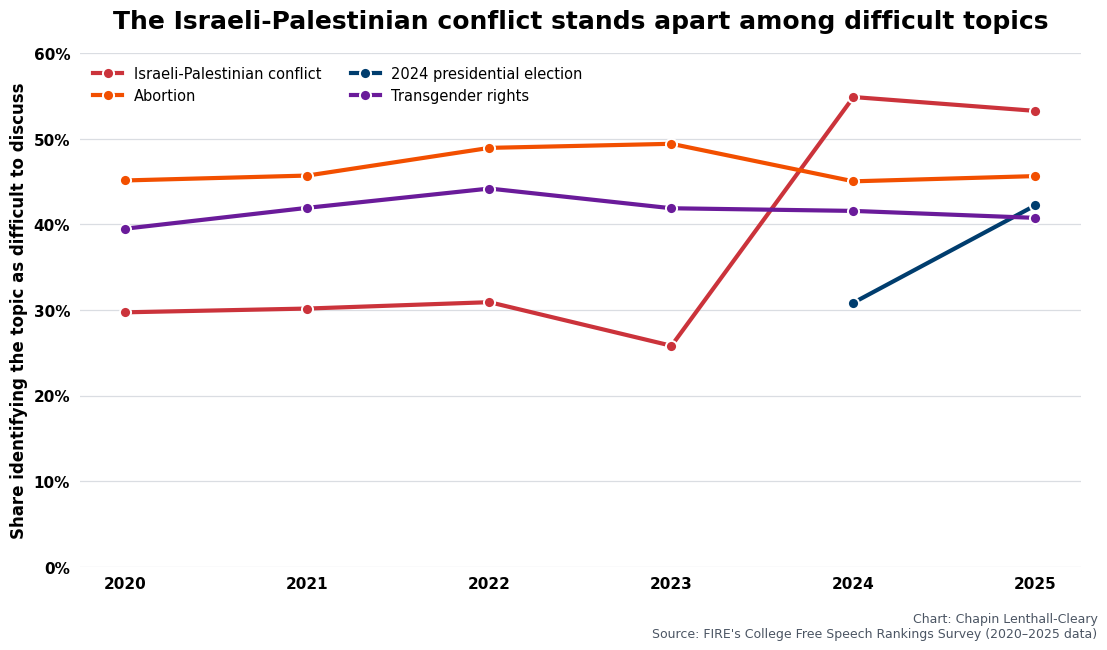

Saved: /Users/chapin.lenthall-cleary/trends_article_outputs/israeli_palestinian_conflict_trend_2020_2025.png


In [6]:
# 5. The four most difficult topics to discuss in 2025
topic_rows = []
for year, year_df in data.groupby(YEAR_COL, sort=True):
    for item, label in DIFFICULT_TOPIC_ITEMS.items():
        valid = year_df[item].isin([0, 1])
        if not valid.any():
            continue
        sub = year_df.loc[valid]
        topic_rows.append({
            "year": int(year),
            "topic": label,
            "percent": weighted_percent(sub[item].eq(1), sub[WEIGHT_COL]),
            "n_valid": int(valid.sum()),
        })
topic_trends = pd.DataFrame(topic_rows)

topic_2025_ranking = (
    topic_trends.loc[topic_trends["year"].eq(2025)]
    .sort_values("percent", ascending=False)
    .reset_index(drop=True)
)
display(topic_2025_ranking.round({"percent": 1}))
display(
    topic_trends.pivot(index="year", columns="topic", values="percent")
    .reindex(columns=DIFFICULT_TOPIC_ITEMS.values())
    .round(1)
)

topic_colors = {
    "Israeli-Palestinian conflict": FIRE["red"],
    "Abortion": FIRE["orange"],
    "2024 presidential election": FIRE["navy"],
    "Transgender rights": FIRE["purple"],
}

fig, ax = plt.subplots(figsize=(11.5, 6.8))
for topic in DIFFICULT_TOPIC_ITEMS.values():
    plot_df = topic_trends.loc[topic_trends["topic"].eq(topic)].sort_values("year")
    ax.plot(
        plot_df["year"],
        plot_df["percent"],
        label=topic,
        color=topic_colors[topic],
        linewidth=3.0,
        marker="o",
        markersize=8,
        markeredgecolor="white",
        markeredgewidth=1.4,
    )

style_axes(
    ax,
    range(2020, 2026),
    ylim=(0, 60),
    ylabel="Share identifying the topic as difficult to discuss",
    percent=True,
)
ax.set_yticks([0, 10, 20, 30, 40, 50, 60])
finish_plot(
    fig,
    ax,
    title="The Israeli-Palestinian conflict stands apart among difficult topics",
    filename="israeli_palestinian_conflict_trend_2020_2025.png",
    chart_credit="Chapin Lenthall-Cleary",
    source_years="2020–2025",
    legend={"frameon": False, "loc": "upper left", "ncol": 2},
)
